<a href="https://colab.research.google.com/github/mohamedzaghloul-lab638/QSAR-modelling---EGFR-/blob/main/EGFR_predictive_model_update.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install chembl_webresource_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 5.1 MB/s eta 0:00:00


In [2]:
from chembl_webresource_client.new_client import new_client
def get_chembl_data(target_name , max_results=1000):
  target=new_client.target
  target_results=target.search(target_name)
  for i,t in enumerate(target_results):
    print(i,t['target_chembl_id'],t['pref_name'],t['organism'])
  return target_results
res= get_chembl_data('EGFR')
target_id=res[0]['target_chembl_id']
print(f'target id is :{target_id}')

/usr/local/lib/python3.13/dist-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


0 CHEMBL4523747 EGFR/PPP1CA Homo sapiens
1 CHEMBL5465557 CCN2-EGFR Homo sapiens
2 CHEMBL3608 Epidermal growth factor receptor Mus musculus
3 CHEMBL6193842 Protein cereblon/Epidermal growth factor receptor Mus musculus
4 CHEMBL203 Epidermal growth factor receptor Homo sapiens
5 CHEMBL4523680 Protein cereblon/Epidermal growth factor receptor Homo sapiens
6 CHEMBL2363049 Epidermal growth factor receptor Homo sapiens
7 CHEMBL3137284 MER intracellular domain/EGFR extracellular domain chimera Homo sapiens
8 CHEMBL4523998 von Hippel-Lindau disease tumor suppressor/Epidermal growth factor receptor Homo sapiens
9 CHEMBL6193841 Protein cereblon/Epidermal growth factor receptor Mus musculus
10 CHEMBL1824 Receptor tyrosine-protein kinase erbB-2 Homo sapiens
11 CHEMBL3848 Receptor tyrosine-protein kinase erbB-2 Rattus norvegicus
12 CHEMBL3009 Receptor tyrosine-protein kinase erbB-4 Homo sapiens
13 CHEMBL5838 Receptor tyrosine-protein kinase erbB-3 Homo sapiens
14 CHEMBL2111431 Epidermal growth fact

In [34]:
import pandas as pd
import numpy as np

def get_chembl_act(target_id,max_results=1000):
  activity=new_client.activity
  results=activity.filter(target_chembl_id=target_id,
                          standard_type='IC50',
                          standard_relation='=',
                          assay_type='B',
                          limit=max_results

                          ).only([
                              'molecule_chembl_id',
            'canonical_smiles',
            'standard_value',
            'standard_units',
            'standard_type',
            'assay_chembl_id',
            'data_validity_comment'                  ])

  df=pd.DataFrame(list(results))
  print(f" number of compounds is : {len(df)}")
  return df

df = get_chembl_act('CHEMBL203')
print(df.shape)
print(df.head())


 number of compounds is : 18454
(18454, 10)
  assay_chembl_id                                   canonical_smiles  \
0    CHEMBL674637  Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...   
1    CHEMBL674637  Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...   
2    CHEMBL677833        CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12   
3    CHEMBL674643             CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1   
4    CHEMBL674643                             O=C(O)/C=C/c1ccc(O)cc1   

   data_validity_comment molecule_chembl_id standard_type standard_units  \
0                   None        CHEMBL68920          IC50             nM   
1                   None        CHEMBL69960          IC50             nM   
2                   None       CHEMBL137635          IC50             nM   
3  Outside typical range       CHEMBL306988          IC50             nM   
4  Outside typical range        CHEMBL66879          IC50             nM   

  standard_value  type units   value  
0           41.0  IC50    u

In [35]:
# filtration
print(df['data_validity_comment'].value_counts(dropna=False))
df_clean2=df[df['data_validity_comment'].isna()].copy()

print(f" number of validity comments before filtration : {len(df)}")
print(f" number of validity comments after filtration : {len(df_clean2)}")


data_validity_comment
None                             18189
Outside typical range              207
Potential transcription error       58
Name: count, dtype: int64
 number of validity comments before filtration : 18454
 number of validity comments after filtration : 18189


In [6]:
from google.colab import files
df_clean2.to_csv('new_EGFR_database.csv',index=False)
files.download('new_EGFR_database.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import pandas as pd
import numpy as np
df_clean2=pd.read_csv('/content/new_EGFR_database.csv')
df_clean2


,assay_chembl_id,canonical_smiles,data_validity_comment,molecule_chembl_id,standard_type,standard_units,standard_value,type,units,value
0,CHEMBL674637,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,NaN,CHEMBL68920,IC50,nM,41.000,IC50,uM,0.041
1,CHEMBL674637,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,NaN,CHEMBL69960,IC50,nM,170.000,IC50,uM,0.170
2,CHEMBL677833,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,NaN,CHEMBL137635,IC50,nM,9300.000,IC50,uM,9.300
3,CHEMBL674643,N#CC(C#N)=Cc1cc(O)ccc1[N+](=O)[O-],NaN,CHEMBL77085,IC50,nM,96000.000,IC50,uM,96.000
4,CHEMBL674637,Cc1cc(C(=O)NCCN2CCOCC2)[nH]c1/C=C1\C(=O)N(C)c2...,NaN,CHEMBL443268,IC50,nM,5310.000,IC50,uM,5.310
...,...,...,...,...,...,...,...,...,...,...
18184,CHEMBL6184534,O=C(CCCCOc1cc2ncnc(Nc3cccc(Cl)c3)c2c2c1OCCO2)NO,NaN,CHEMBL6191667,IC50,nM,9.800,IC50,nM,9.800
18185,CHEMBL6184534,O=C(CCCCCOc1cc2ncnc(Nc3ccccc3Cl)c2c2c1OCCO2)NO,NaN,CHEMBL6192203,IC50,nM,130.100,IC50,nM,130.100
18186,CHEMBL6184534,O=C(CCCCCOc1cc2ncnc(Nc3cccc(Cl)c3)c2c2c1OCCO2)NO,NaN,CHEMBL6191199,IC50,nM,4.810,IC50,nM,4.810
18187,CHEMBL6184534,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,NaN,CHEMBL939,IC50,nM,13.080,IC50,nM,13.080


In [2]:
print(f"df {len(df)}")
print(f"df_clean {len(df_clean2)}")

NameError: name 'df' is not defined

In [3]:
print(f" df_clean as a start : {len(df_clean2)}")
df_clean3=df_clean2[['canonical_smiles','standard_type','standard_value','standard_units','molecule_chembl_id']]
print(f" df_clean3 after selection : {len(df_clean3)}")




 df_clean as a start : 18189
 df_clean3 after selection : 18189


In [4]:
print(df_clean3.isna().sum())

canonical_smiles      17
standard_type          0
standard_value         1
standard_units         0
molecule_chembl_id     0
dtype: int64


In [5]:
df_final=df_clean3.dropna()
print(f"number of smiles after curation:{len(df_final)}")

number of smiles after curation:18171


In [6]:
# IC50 to PIC50
df_final=df_final[df_final['standard_units']=='nM']
df_final_PIC50=df_final.copy()
df_final_PIC50['standard_value']=pd.to_numeric(df_final_PIC50['standard_value'],errors='coerce')
df_final_PIC50=df_final_PIC50[df_final_PIC50['standard_value']>0]
df_final_PIC50['PIC50']=-np.log10(df_final_PIC50['standard_value']*1e-9)
df_final_PIC50

,canonical_smiles,standard_type,standard_value,standard_units,molecule_chembl_id,PIC50
0,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,IC50,41.000,nM,CHEMBL68920,7.387216
1,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,IC50,170.000,nM,CHEMBL69960,6.769551
2,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,IC50,9300.000,nM,CHEMBL137635,5.031517
3,N#CC(C#N)=Cc1cc(O)ccc1[N+](=O)[O-],IC50,96000.000,nM,CHEMBL77085,4.017729
4,Cc1cc(C(=O)NCCN2CCOCC2)[nH]c1/C=C1\C(=O)N(C)c2...,IC50,5310.000,nM,CHEMBL443268,5.274905
...,...,...,...,...,...,...
18184,O=C(CCCCOc1cc2ncnc(Nc3cccc(Cl)c3)c2c2c1OCCO2)NO,IC50,9.800,nM,CHEMBL6191667,8.008774
18185,O=C(CCCCCOc1cc2ncnc(Nc3ccccc3Cl)c2c2c1OCCO2)NO,IC50,130.100,nM,CHEMBL6192203,6.885723
18186,O=C(CCCCCOc1cc2ncnc(Nc3cccc(Cl)c3)c2c2c1OCCO2)NO,IC50,4.810,nM,CHEMBL6191199,8.317855
18187,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,IC50,13.080,nM,CHEMBL939,7.883392


In [7]:
print(f"current number : {len(df_final)}")

# median aggregation of duplicates
df_final_agg = df_final_PIC50.groupby('canonical_smiles', as_index=False).agg({
    'PIC50': 'median',
    'molecule_chembl_id': 'first'
})
print(f" median after agg: {len(df_final_agg)}")

print(df_final_agg['PIC50'].describe())

current number : 18106
 median after agg: 10407
count    10407.000000
mean         6.984340
std          1.309539
min          4.000000
25%          6.023312
50%          7.075721
75%          8.000000
max         11.000000
Name: PIC50, dtype: float64


In [8]:
if df_final_agg.isna().sum().sum() ==0 :
  print ("ready to GO")
else :
     print ("still need some curation")

ready to GO


In [9]:
len(df_final_agg)

10407

In [10]:
! pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 47.2 MB/s eta 0:00:00


In [11]:
from rdkit import Chem
from rdkit.Chem import Descriptors, DataStructs , rdFingerprintGenerator
# smiles function
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def get_smi (smi) :
  mol=Chem.MolFromSmiles(smi)
  fp=gen.GetFingerprint(mol)
  return np.array(fp)
# descs function
def get_desc(smi):
  mol=Chem.MolFromSmiles(smi)
  return np.array([Descriptors.ExactMolWt(mol),
      Descriptors.MolLogP(mol),
      Descriptors.TPSA(mol),
      Descriptors.NumHDonors(mol),
      Descriptors.NumHAcceptors(mol)])
 # concatentaion
def get_features(smi):
 fps=get_smi(smi)
 desc=get_desc(smi)
 features=np.concatenate([fps,desc])
 return features


In [12]:
# apply function
df_final_agg.reset_index(drop=True,inplace=True) # to avoid errors of indexing after filtering
features_list=[get_features(smi) for smi in df_final_agg['canonical_smiles']]
validation=[i for i,f in enumerate(features_list) if f is None]
df_final_agg=df_final_agg.drop(index=validation).reset_index(drop=True)

In [13]:
x=np.array(features_list)
y=np.array(df_final_agg['PIC50'])
print(x.shape,y.shape)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

(10407, 2053) (10407,)


In [14]:
MSE=mean_squared_error(y_test,y_pred)
R2=r2_score(y_test,y_pred)
print(f"MSE : {MSE}")
print(f"R2 : {R2}")

MSE : 0.5132893788015104
R2 : 0.696304073235963


In [15]:
#XG
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators=200,learning_rate=0.05 , subsample=0.8 , colsample_bytree=0.8, max_depth=6, random_state=42, n_jobs=-1)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R2: {r2}")

MSE: 0.6357413996162241
R2: 0.623853363205132


In [16]:
from sklearn.ensemble import HistGradientBoostingRegressor
model = HistGradientBoostingRegressor(max_iter=300 , learning_rate=0.05, max_depth=6, random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R2: {r2}")

MSE: 0.6445664664694389
R2: 0.618631870286265


In [17]:
from sklearn.neighbors import KNeighborsRegressor

n_train = len(x_train)
k_estimate = int(np.sqrt(n_train))

for k in [5, 10, 20, k_estimate]:
    model = KNeighborsRegressor(n_neighbors=k, metric='jaccard')
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print(f"k={k}: R2={r2_score(y_test, y_pred):.3f}")
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


k=5: R2=0.683


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


k=10: R2=0.658


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


k=20: R2=0.599


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


k=91: R2=0.446


KNeighborsRegressor()

In [19]:
for k in [1, 3, 5, 7 ]:
    model = KNeighborsRegressor(n_neighbors=k, metric='jaccard')
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print(f"k={k}: R2={r2_score(y_test, y_pred):.3f}")


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


k=1: R2=0.570


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


k=3: R2=0.683


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


k=5: R2=0.683


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


k=7: R2=0.673


In [29]:
n_fp = 2048

x_train_fp = x_train[:, :n_fp]
x_test_fp = x_test[:, :n_fp]

for k in [3, 5, 7, 10, 15, 20]:
    model = KNeighborsRegressor(n_neighbors=k, metric='jaccard')
    model.fit(x_train_fp, y_train)
    y_pred = model.predict(x_test_fp)
    print(f"k={k}: R2={r2_score(y_test, y_pred):.3f}")

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


k=3: R2=0.684


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


k=5: R2=0.680


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


...

k=10: R2=0.655


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


k=15: R2=0.622


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


k=20: R2=0.598


In [32]:
# feature selection
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
x_train_selected = selector.fit_transform(x_train)
x_test_selected = selector.transform(x_test)
print(f" before Features : {x_train.shape[1]}, after: {x_train_selected.shape[1]}")

 before Features : 2053, after: 883


In [34]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.001)
x_train_selected = selector.fit_transform(x_train)
x_test_selected = selector.transform(x_test)
print(f" before Features : {x_train.shape[1]}, after: {x_train_selected.shape[1]}")

 before Features : 2053, after: 1982


In [35]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.02)
x_train_selected = selector.fit_transform(x_train)
x_test_selected = selector.transform(x_test)
print(f" before Features : {x_train.shape[1]}, after: {x_train_selected.shape[1]}")

 before Features : 2053, after: 517


In [36]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.03)
x_train_selected = selector.fit_transform(x_train)
x_test_selected = selector.transform(x_test)
print(f" before Features : {x_train.shape[1]}, after: {x_train_selected.shape[1]}")

 before Features : 2053, after: 360


In [37]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.04)
x_train_selected = selector.fit_transform(x_train)
x_test_selected = selector.transform(x_test)
print(f" before Features : {x_train.shape[1]}, after: {x_train_selected.shape[1]}")

 before Features : 2053, after: 288


In [38]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.05)
x_train_selected = selector.fit_transform(x_train)
x_test_selected = selector.transform(x_test)
print(f" before Features : {x_train.shape[1]}, after: {x_train_selected.shape[1]}")

 before Features : 2053, after: 233


In [40]:
# feature selection
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
x_train_selected = selector.fit_transform(x_train)
x_test_selected = selector.transform(x_test)
print(f" before Features : {x_train.shape[1]}, after: {x_train_selected.shape[1]}")

 before Features : 2053, after: 883


In [41]:
X_train_selected = selector.fit_transform(x_train)
X_test_selected = selector.transform(x_test)

models = {
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, random_state=42)
}

for name, model in models.items():
    model.fit(x_train_selected, y_train)
    y_pred = model.predict(x_test_selected)
    print(f"{name}: MSE={mean_squared_error(y_test, y_pred):.3f}, R2={r2_score(y_test, y_pred):.3f}")

Random Forest: MSE=0.511, R2=0.698
HistGradientBoosting: MSE=0.616, R2=0.636
XGBoost: MSE=0.527, R2=0.688


In [42]:
# NN
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [43]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

mlp = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,              # L2 regularization
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

mlp.fit(x_train_scaled, y_train)
y_pred = mlp.predict(x_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MLP MSE: {mse:.3f}")
print(f"MLP R2: {r2:.3f}")

MLP MSE: 0.690
MLP R2: 0.592


In [44]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(256, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = model.fit(
    x_train_scaled, y_train,
    validation_split=0.1,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

y_pred = model.predict(x_test_scaled).flatten()
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"NN MSE: {mse:.3f}")
print(f"NN R2: {r2:.3f}")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 3.7019 - mae: 1.4266 - val_loss: 1.8778 - val_mae: 1.0992
Epoch 2/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.6681 - mae: 1.0165 - val_loss: 3.0131 - val_mae: 1.5138
Epoch 3/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.3606 - mae: 0.9261 - val_loss: 2.4437 - val_mae: 1.3414
Epoch 4/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.1505 - mae: 0.8421 - val_loss: 1.9209 - val_mae: 1.1783
Epoch 5/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.0066 - mae: 0.7961 - val_loss: 2.4605 - val_mae: 1.3666
Epoch 6/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.9202 - mae: 0.7599 - val_loss: 2.7053 - val_mae: 1.4432
Epoch 7/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8410 - mae: 0.7192 - val_loss: 3.4034 - val_mae: 1.6526
Epoch 8/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.7849 - mae: 0.6924 - val_loss: 2.4016 - val_mae: 1.3509
Epoch 9/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/

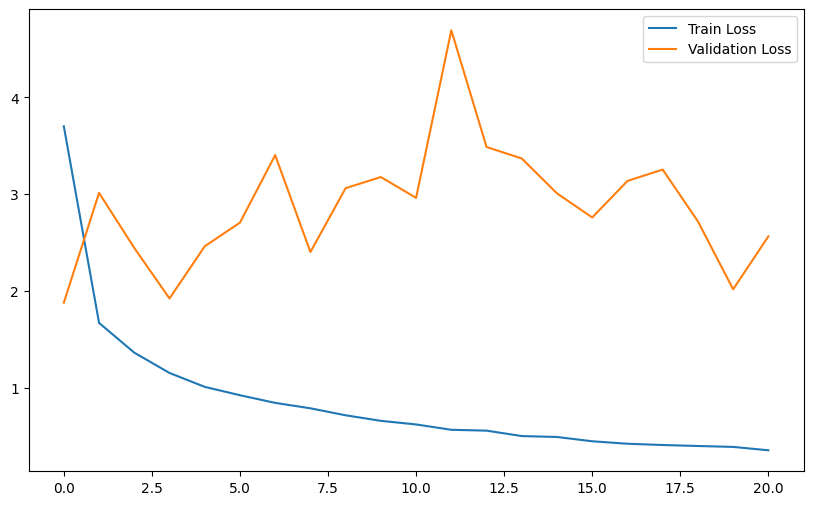

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [48]:
from tensorflow.keras.regularizers import l2

model = Sequential([
    Dense(64, activation='relu', input_shape=(x_train_scaled.shape[1],),
          kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(1)
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    x_train_scaled, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 32.8891 - val_loss: 5.7487
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 13.2540 - val_loss: 5.0648
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 11.3997 - val_loss: 4.4312
Epoch 4/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 10.4537 - val_loss: 4.4824
Epoch 5/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 9.6075 - val_loss: 4.1423
Epoch 6/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9.0113 - val_loss: 4.1622
Epoch 7/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.6295 - val_loss: 3.5262
Epoch 8/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.2809 - val_loss: 3.5858
Epoch 9/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.7566 - val_loss: 3.3972
Epoch 10/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.4583 - val_loss: 3.4004
Epoch 11/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.2958 - val_loss: 3.1804
Epoch 12/100
118/118 ━━━━━━━━━━━

In [49]:
y_pred = model.predict(x_test_scaled).flatten()
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"NN MSE: {mse:.3f}")
print(f"NN R2: {r2:.3f}")

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
NN MSE: 0.693
NN R2: 0.590


In [ ]:
# let's try scaffold-based split instaed of Random split

In [59]:
# grouped scaffold-based split
from rdkit.Chem.Scaffolds import MurckoScaffold
def get_scaffold(smi):
  mol=Chem.MolFromSmiles(smi)
  scaffold=MurckoScaffold.GetScaffoldForMol(mol)
  return Chem.MolToSmiles(scaffold)

df_final_agg['scaffold']=[get_scaffold(smi) for smi in df_final_agg['canonical_smiles']]

In [60]:
from collections import defaultdict
scaffold_groups = defaultdict(list)
for idx, scaf in zip(df_final_agg.index, df_final_agg['scaffold']):
    scaffold_groups[scaf].append(idx)

groups = sorted(scaffold_groups.values(), key=len, reverse=True)

print(f"  number of scaffolds is : {len(groups)}")

  number of scaffolds is : 3835


In [61]:
# grouping
train_idx, test_idx = [], []
test_size_target = 0.2 * len(df_final_agg)

for group in groups:
    if len(test_idx) < test_size_target:
        test_idx.extend(group)
    else:
        train_idx.extend(group)

print(f"Train: {len(train_idx)} compounds")
print(f"Test: {len(test_idx)} compounds")

Train: 8319 compounds
Test: 2088 compounds


In [62]:
x_train, x_test = x[train_idx], x[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"X_train: {x_train.shape}, X_test: {x_test.shape}")

X_train: (8319, 2053), X_test: (2088, 2053)


In [63]:
# re-training

model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R2: {r2}")

MSE: 0.7343217254691633
R2: 0.5849280772492003


In [17]:
print(f"numver of unique scaffolds is: {df_clean_PIC50['scaffold'].nunique()}")
print(f"number of mols is : {len(df_clean_PIC50)}")


numver of unique scaffolds is: 3776
number of mols is : 17628


In [18]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.Scaffolds.MurckoScaffold import MakeScaffoldGeneric

def get_generic_scaffold(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    try:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        generic = MakeScaffoldGeneric(scaffold)
        return Chem.MolToSmiles(generic)
    except:
        return None

df_clean_PIC50['generic_scaffold'] = [get_generic_scaffold(smi) for smi in df_clean_PIC50['canonical_smiles']]

print(f" Nones: {df_clean_PIC50['generic_scaffold'].isna().sum()}")

n_murcko = df_clean_PIC50['scaffold'].nunique()
n_generic = df_clean_PIC50['generic_scaffold'].nunique()

print(f" unique Murcko scaffolds : {n_murcko}")
print(f" Generic scaffolds : {n_generic}")
print(f"diversity reasoning : {(1 - n_generic/n_murcko):.1%}")

 Nones: 0
 unique Murcko scaffolds : 3776
 Generic scaffolds : 2226
diversity reasoning : 41.0%


In [ ]:
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.ensemble import RandomForestRegressor

scaffolds_train = df_clean_PIC50['scaffold'].values[train_idx]

gkf = GroupKFold(n_splits=5)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
}

GD = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    n_jobs=-1,
    cv=gkf.split(x_train, y_train, groups=scaffolds_train),
    scoring='r2',
    verbose=2
)

GD.fit(x_train, y_train)

print(f"best param : {GD.best_params_}")
print(f" best R² in CV: {GD.best_score_:.3f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [19]:
# Descision tree-based alogo
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators=200,learning_rate=0.05 , subsample=0.8 , colsample_bytree=0.8, max_depth=6, random_state=42, n_jobs=-1)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R2: {r2}")

MSE: 1.250659302174984
R2: 0.320183113153107


In [21]:
from sklearn.ensemble import HistGradientBoostingRegressor
model = HistGradientBoostingRegressor(max_iter=300 , learning_rate=0.05, max_depth=6, random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R2: {r2}")

MSE: 1.2352161940346849
R2: 0.3285774741760653


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
svm= Pipeline ([
    ('scaler' , StandardScaler()) ,
    ('svm' , SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1))])

model=svm.fit(x_train, y_train)
y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R2: {r2}")

MSE: 1.9339108625005863
R2: -0.05120975768394631
